In [ ]:
!pip install --upgrade --force-reinstall fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2

In [ ]:
#!pip uninstall -y numpy
#!pip uninstall -y pandas
#!pip install numpy==1.25.2
#!pip install pandas==2.0.3

In [ ]:
# ─────────────────────────────────────────────────────────────────
# IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')   # Silenciar advertencias no críticas

from matplotlib import style
import matplotlib.ticker as ticker

# Aplicar el estilo ggplot
style.use('ggplot')
plt.rcParams['figure.dpi'] = 100

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


# Definir Problema ¿Qué se pretende predecir?:

Queremos predecir el precio de las viviendas (Price) basándonos en variables Fisicas-demográficas y Calidad del Inmueble y su entorno.

# De que datos se disponen:
Se cuenta con el dataset `housing_dataset_1200`, que contiene **1,200 registros** y **8 variables**:

| Variable | Tipo | Descripción |
|---|---|---|
| `Income` | Numérica | Ingreso promedio del vecindario |
| `HouseAge` | Numérica | Antigüedad de la vivienda en años |
| `Rooms` | Numérica | Número de habitaciones totales |
| `Bedrooms` | Numérica | Número de dormitorios |
| `Population` | Numérica | Población del área |
| `Location` | Cualitativa | Tipo de zona: Urban, Suburban, Rural |
| `Quality` | Cualitativa | Calidad de la vivienda: High, Medium, Low |
| `Price` | Numérica (**variable objetivo**) | Precio de la vivienda en USD |

# Que Datos Serian Necesarios conseguir:

En este caso, el dataset ya viene "limpio" (pro), pero en un escenario real, sería ideal conseguir datos como:

La cercanía a servicios (Metro, colegios).

Metros cuadrados exactos del terreno.

Tasas de criminalidad del sector.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = '/content/drive/MyDrive/housing_dataset_1200.csv'
datos = pd.read_csv(ruta)

# Mostrar las primeras filas
datos.head()

,Income,HouseAge,Rooms,Bedrooms,Population,Location,Quality,Price
0,NaN,26.0,3.0,3.0,48675.0,Rural,High,298110.924325
1,62926.035482,34.0,8.0,7.0,65249.0,NaN,Medium,404494.649131
2,74715.328072,6.0,3.0,3.0,58895.0,Rural,Low,396632.249630
3,87845.447846,37.0,5.0,4.0,38937.0,Urban,High,395118.738127
4,61487.699379,33.0,7.0,6.0,15656.0,Suburban,Medium,321036.705636


In [ ]:
# Cantidad de Observaciones y variables

datos.shape

(1200, 8)

In [ ]:
# Tipo de Datos contiene cada columna

datos.dtypes

Income        float64
HouseAge      float64
Rooms         float64
Bedrooms      float64
Population    float64
Location          str
Quality           str
Price         float64
dtype: object

# PUNTO 2: Exploración y Entendimiento de los Datos

In [ ]:
# PUNTO 2 - Estadística Descriptiva de las Variables Numéricas

datos.select_dtypes(include=np.number).describe()

,Income,HouseAge,Rooms,Bedrooms,Population,Price
count,1134.000000,1200.000000,1134.000000,1200.000000,1200.000000,1200.000000
mean,64889.023957,20.382831,5.898373,4.981988,41557.597111,367125.128097
std,14965.853149,11.298372,1.925692,2.106479,16904.131985,75213.009499
min,19026.378818,0.490430,2.764828,0.893953,9459.468098,152003.557496
25%,53781.691225,10.042329,4.037819,3.121915,27339.347567,315776.193209
50%,64848.354394,21.000000,6.000000,4.998048,41053.039713,368769.250897
75%,74415.648749,30.000000,7.817570,6.918738,55882.635955,413968.673837
max,112247.017576,40.090730,9.286159,9.187501,70935.423557,579402.558422


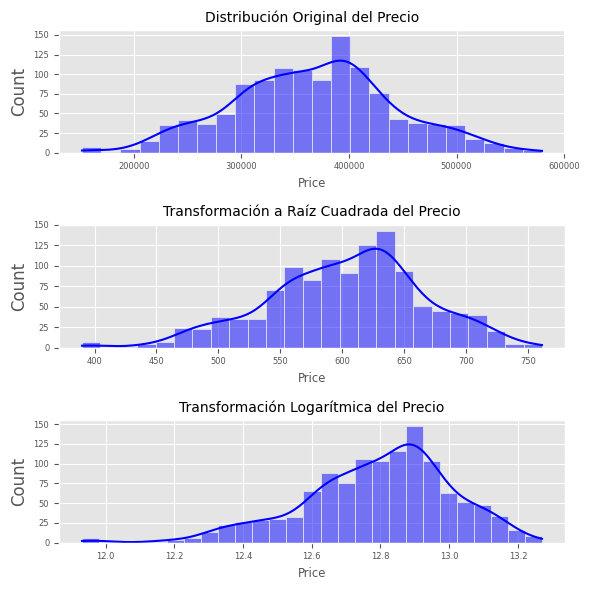

In [ ]:
# PUNTO 2 - Distribución de la variable respuesta Price

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 6))

sns.histplot(datos['Price'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribución Original del Precio', fontsize='medium')
axes[0].set_xlabel('Price', fontsize='small')
axes[0].tick_params(labelsize=6)

sns.histplot(np.sqrt(datos['Price']), kde=True, color='blue', ax=axes[1])
axes[1].set_title('Transformación a Raíz Cuadrada del Precio', fontsize='medium')
axes[1].set_xlabel('Price', fontsize='small')
axes[1].tick_params(labelsize=6)

sns.histplot(np.log(datos['Price']), kde=True, color='blue', ax=axes[2])
axes[2].set_title('Transformación Logarítmica del Precio', fontsize='medium')
axes[2].set_xlabel('Price', fontsize='small')
axes[2].tick_params(labelsize=6)

fig.tight_layout()
plt.show()

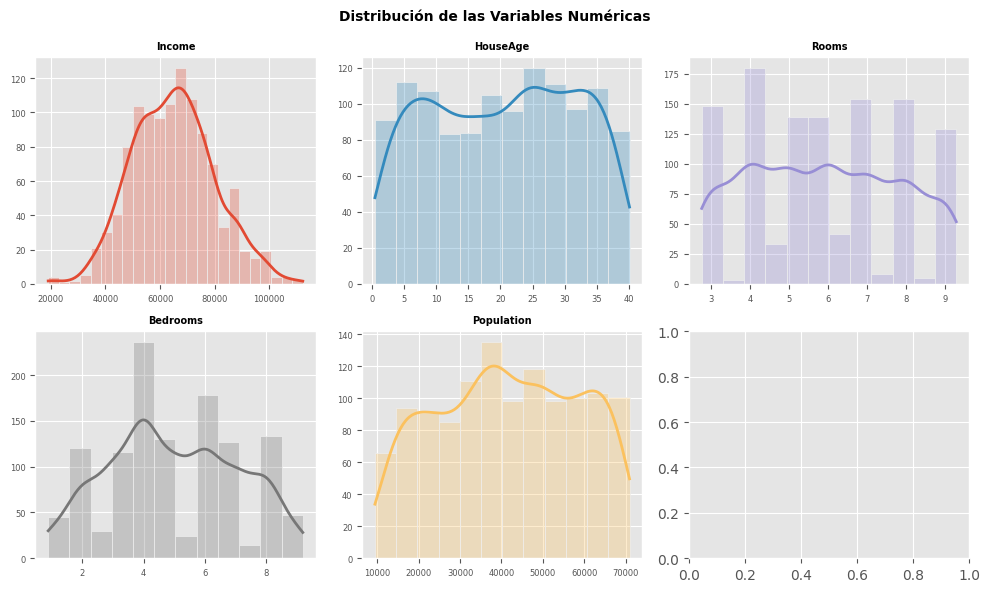

In [ ]:
# PUNTO 2 - Distribución de las Variables Numéricas

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes = axes.flat

columnas_numericas = datos.select_dtypes(include=np.number).columns
columnas_numericas = columnas_numericas.drop('Price')

for i, columna in enumerate(columnas_numericas):
    sns.histplot(
        data=datos,
        x=columna,
        stat='count',
        kde=True,
        color=list(plt.rcParams['axes.prop_cycle'] * 2)[i]['color'],
        line_kws={'linewidth': 2},
        alpha=0.3,
        ax=axes[i])

    axes[i].set_title(columna, fontsize=7, fontweight='bold')
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribución de las Variables Numéricas', fontsize='medium', fontweight='bold')
plt.show()

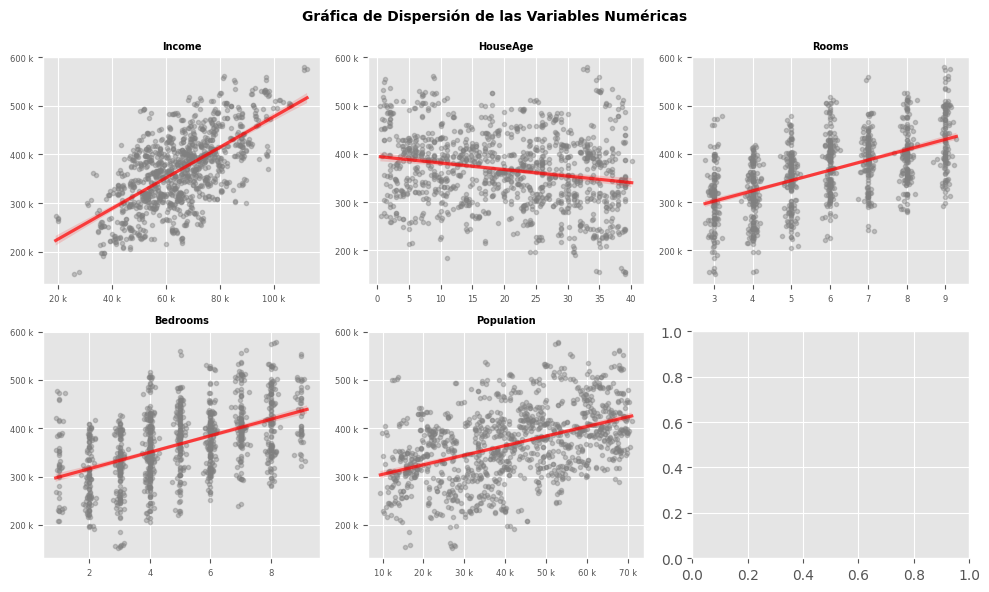

In [ ]:
# PUNTO 2 - Gráfica de Dispersión: Variables Numéricas vs Price

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes = axes.flat
columnas_numericas = datos.select_dtypes(include=np.number).columns
columnas_numericas = columnas_numericas.drop('Price')

for i, columna in enumerate(columnas_numericas):
    sns.regplot(
        data=datos,
        x=datos[columna],
        y='Price',
        color='gray',
        marker='.',
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'red', 'alpha': 0.7},
        ax=axes[i])

    axes[i].set_title(columna, fontsize=7, fontweight='bold')
    axes[i].tick_params(labelsize=6)
    axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
    axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Gráfica de Dispersión de las Variables Numéricas', fontsize='medium', fontweight='bold')
plt.show()

In [ ]:
# PUNTO 2 - Matriz de Correlación entre Variables Numéricas

def matriz_correlacion(corr_mat):
    """Función para convertir una matriz de correlación a formato DataFrame"""
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1', 'variable_2', 'correlacion']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['Absoluto'] = np.abs(corr_mat['correlacion'])
    corr_mat = corr_mat.sort_values('Absoluto', ascending=False)
    return corr_mat


corr_matrix = datos.select_dtypes(include=np.number).corr(method='pearson')
matriz_correlacion(corr_matrix).head(10)

,variable_1,variable_2,correlacion,Absoluto
15,Rooms,Bedrooms,0.920511,0.920511
20,Bedrooms,Rooms,0.920511,0.920511
30,Price,Income,0.631467,0.631467
5,Income,Price,0.631467,0.631467
17,Rooms,Price,0.554454,0.554454
32,Price,Rooms,0.554454,0.554454
33,Price,Bedrooms,0.479319,0.479319
23,Bedrooms,Price,0.479319,0.479319
34,Price,Population,0.445712,0.445712
29,Population,Price,0.445712,0.445712


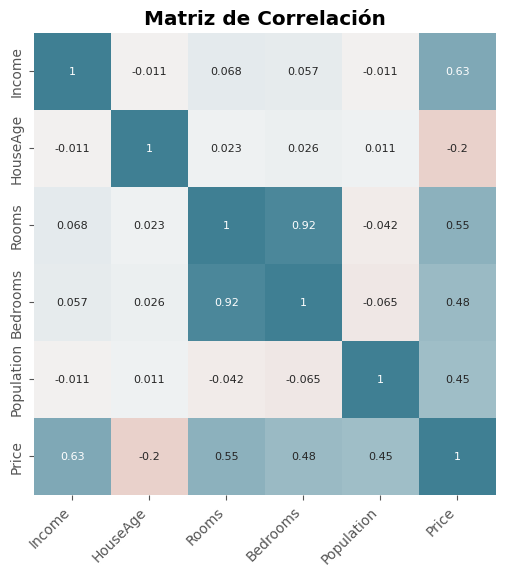

In [ ]:
# PUNTO 2 - HeatMap de Correlaciones

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 6))

sns.heatmap(
    corr_matrix,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={'fontsize': 8},
    cbar=False,
    ax=axes)

axes.set_xticklabels(axes.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Matriz de Correlación', fontweight='bold')
plt.show()

### Análisis de Variables Cualitativas
Las variables cualitativas `Location` y `Quality` describen características categóricas de la vivienda. Se analiza su distribución y su relación con el precio mediante gráficas de violin.


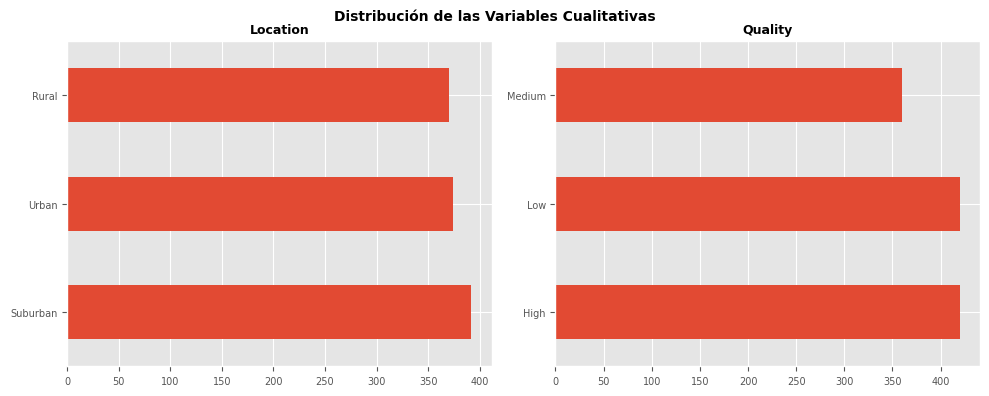

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include='object').columns

for i, columna in enumerate(columnas_cualitativas):
    datos[columna].value_counts().plot(
        kind='barh',
        ax=axes[i])
    axes[i].set_title(columna, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribución de las Variables Cualitativas', fontsize='medium', fontweight='bold')
plt.show()

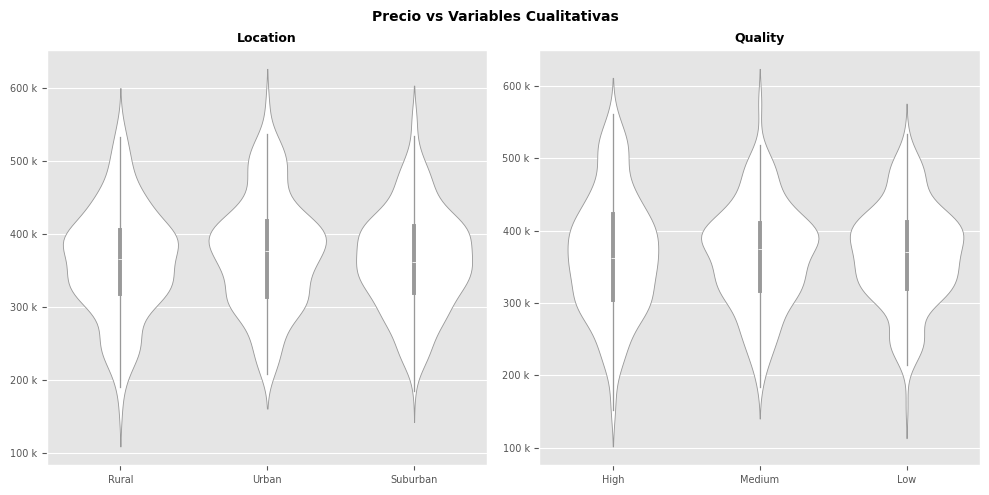

In [ ]:
# PUNTO 2 - Relación entre Price y Variables Cualitativas (Violin Plot)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include='object').columns

for i, columna in enumerate(columnas_cualitativas):
    sns.violinplot(
        data=datos,
        x=columna,
        y='Price',
        color='white',
        ax=axes[i])

    axes[i].set_title(columna, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].yaxis.set_major_formatter(ticker.EngFormatter())

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Precio vs Variables Cualitativas', fontsize='medium', fontweight='bold')
plt.show()

# PUNTO 3: Definición de la Métrica de Éxito

Para medir el rendimiento de los modelos de regresión se utilizará el **Coeficiente de Determinación R²** como métrica principal. Esta métrica indica qué proporción de la varianza de la variable objetivo (`Price`) es explicada por el modelo.

**Interpretación del R²:**
- R² < 0.5 → Ajuste débil
- 0.5 ≤ R² ≤ 0.8 → Ajuste moderado  
- R² > 0.8 → Ajuste fuerte

También se reportarán como métricas complementarias:
- **MAE** (Mean Absolute Error): Error promedio absoluto en USD
- **RMSE** (Root Mean Squared Error): Penaliza más los errores grandes

# PUNTO 4: División del Conjunto de Datos en Train y Test

Se divide el dataset en 80% para entrenamiento y 20% para prueba. Esta proporción es estándar en Machine Learning y permite que el modelo tenga suficientes datos para aprender, mientras se reserva un conjunto independiente para evaluar su capacidad de generalización.

In [ ]:
# PUNTO 4 - División Train-Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos.drop('Price', axis='columns'),
    datos.Price,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    shuffle=True)

print('Resultado de la Partición de los Datos de Entrenamiento')
print('-------------------------------------------------------')
print(y_train.describe())
print('-------------------------------------------------------')

Resultado de la Partición de los Datos de Entrenamiento
-------------------------------------------------------
count       960.000000
mean     367402.906186
std       73872.470653
min      154621.629438
25%      317077.550586
50%      369407.476979
75%      411705.423808
max      579402.558422
Name: Price, dtype: float64
-------------------------------------------------------


In [ ]:
# PUNTO 4 - Verificación del conjunto de prueba

print('Resultado de la Partición de los Datos de Prueba')
print('-------------------------------------------------------')
print(y_test.describe())
print('-------------------------------------------------------')

Resultado de la Partición de los Datos de Prueba
-------------------------------------------------------
count       240.000000
mean     366014.015745
std       80504.935990
min      152003.557496
25%      310782.623089
50%      367504.367228
75%      418929.890602
max      574504.395726
Name: Price, dtype: float64
-------------------------------------------------------


# PUNTO 5: Creación del Pipeline de Preprocesamiento

El preprocesamiento engloba todas las transformaciones necesarias para que los datos puedan ser interpretados eficientemente por el algoritmo. Se construye un Pipeline que aplica de forma **paralela** (no secuencial) las transformaciones a las columnas numéricas y cualitativas:

1. **Imputación de valores ausentes:** Se reemplazan los valores faltantes en variables numéricas con la **mediana** y en variables cualitativas con la **moda**.
2. **Estandarización:** Se aplica `StandardScaler` a las variables numéricas para que tengan media 0 y desviación estándar 1.
3. **Binarización (One-Hot Encoding):** Las variables cualitativas `Location` y `Quality` se convierten en variables dummy.
4. **`ColumnTransformer`:** Aplica las transformaciones de forma paralela a cada grupo de columnas.

**¿Por qué Ridge Regression como primer modelo?**  
Se elige **Ridge Regression** porque es una regresión lineal con regularización L2, lo que penaliza coeficientes muy grandes y reduce el sobreajuste. Es ideal como modelo base porque es interpretable, eficiente y robusto ante multicolinealidad (por ejemplo, la alta correlación entre `Rooms` y `Bedrooms`).

In [ ]:
# PUNTO 5 - Importación de librerías para el pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# PUNTO 5 - Construcción del Pipeline con Preprocesamiento y Modelo Ridge

columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

# Transformaciones de Variables Numéricas: imputar por mediana y escalar
transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformaciones de Variables Cualitativas: imputar por moda y binarizar
transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Unificamos los Pipelines para aplicarlos de forma paralela a las columnas
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

# Pipeline completo: preprocesamiento + modelo
pipe = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])

# Ajustamos el pipeline base aquí para que esté disponible para predicciones futuras
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numericas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'HouseAge',
                                                   'Rooms', 'Bedrooms',
                                                   'Population']),
                                                 ('cualitativas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Quality'])])),
                ('modelo', Ridge())])

## PUNTO 5 - Revisión de Resultados del Primer Modelo

Se evalúa el rendimiento del modelo Ridge con los parámetros por defecto sobre el conjunto de prueba.

In [ ]:
# PUNTO 5 - Predicciones y métricas del primer modelo

# Incluyendo las definiciones de pipe_ridge y sus dependencias para resolver NameError,
# en caso de que las celdas anteriores no se hayan ejecutado en orden o su estado se haya perdido.
# Esto asegura que pipe_ridge esté disponible para la predicción en esta celda.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Redefiniendo los componentes necesarios para preprocesamiento y pipe_ridge:
# Estas variables deberían estar definidas en celdas precedentes,
# pero se incluyen aquí para asegurar la ejecución en caso de NameError.
# Asumiendo que X_train, X_test, y_train, y_test y np están definidos globalmente.

# Redefinir columnas_numericas y columnas_cualitativas
columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

# Redefinir transformacion_numerica
transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Redefinir transformacion_cualitativa
transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Redefinir preprocesamiento
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

# Redefinir pipe_ridge y entrenarlo
pipe_ridge = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])
_ = pipe_ridge.fit(X_train, y_train)


predicciones = pipe_ridge.predict(X_test)

r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print('=== RESULTADOS PRIMER MODELO (Ridge - Parámetros por defecto) ===')
print(f'R²  : {r2:.4f}')
print(f'MAE : ${mae:,.2f}')
print(f'RMSE: ${rmse:,.2f}')

=== RESULTADOS PRIMER MODELO (Ridge - Parámetros por defecto) ===
R²  : 0.8734
MAE : $21,203.39
RMSE: $28,583.61


In [ ]:
# PUNTO 5 - Validación Cruzada del primer modelo

from sklearn.model_selection import cross_val_score, RepeatedKFold

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

cv_scores = cross_val_score(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring='r2'
)

print(f'Métricas de Validación Cruzada: {cv_scores.round(4)}')
print(f'Promedio R² CV: {cv_scores.mean():.4f}')

Métricas de Validación Cruzada: [0.9072 0.8963 0.8713 0.8975 0.8783 0.8742 0.9009 0.87   0.8982 0.9101
 0.9112 0.8767 0.8961 0.8643 0.9032]
Promedio R² CV: 0.8904


# PUNTO 6: Ajuste del Primer Modelo - Optimización de Hiperparámetros

Para el modelo Ridge, el principal hiperparámetro es **alpha** (parámetro de regularización). Se utiliza **RandomizedSearchCV** para buscar el valor óptimo de alpha en un rango logarítmico, junto con la opción de incluir características polinómicas para capturar relaciones no lineales.

In [ ]:
# PUNTO 6 - Optimización del Modelo Ridge con RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures
import multiprocessing

columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

pipe_ridge = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('interacciones', PolynomialFeatures(degree=2)),
    ('modelo', Ridge())
])

param_grid_ridge = {
    'interacciones': [PolynomialFeatures(degree=2), 'passthrough'],
    'modelo__alpha': np.logspace(-5, 3, 50)
}

random_ridge = RandomizedSearchCV(
    estimator=pipe_ridge,
    param_distributions=param_grid_ridge,
    scoring='r2',
    n_jobs=multiprocessing.cpu_count() - 1,
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    refit=True,
    return_train_score=True,
    verbose=0,
    n_iter=30,
    random_state=42
)

random_ridge.fit(X_train, y_train)

print('Mejores Hiperparámetros Ridge:')
print(random_ridge.best_params_)
print(f'Mejor R² CV: {random_ridge.best_score_:.4f}')

Mejores Hiperparámetros Ridge:
{'modelo__alpha': np.float64(23.29951810515367), 'interacciones': PolynomialFeatures()}
Mejor R² CV: 0.8976


In [ ]:
# PUNTO 6 - Error del modelo Ridge optimizado sobre el conjunto de prueba

modelo_ridge_opt = random_ridge.best_estimator_
pred_ridge = modelo_ridge_opt.predict(X_test)
r2_ridge = r2_score(y_test, pred_ridge)

print(f'=== Ridge Optimizado ===' )
print(f'R²  : {r2_ridge:.4f}')
print(f'MAE : ${mean_absolute_error(y_test, pred_ridge):,.2f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, pred_ridge)):,.2f}')

=== Ridge Optimizado ===
R²  : 0.8842
MAE : $20,572.47
RMSE: $27,333.00


# PUNTO 7: Comparación de al Menos 3 Modelos de Regresión

Se entrenan y optimizan tres modelos adicionales para comparar su rendimiento con el modelo Ridge:

1. **K-Nearest Neighbors (KNN):** Modelo no paramétrico que predice con base en los vecinos más cercanos. Se optimiza el hiperparámetro `n_neighbors`.
2. **Random Forest Regressor:** Ensemble de árboles de decisión entrenados en paralelo (bagging). Se optimizan `n_estimators`, `max_depth` y `max_features`.
3. **Gradient Boosting Regressor:** Ensemble secuencial donde cada árbol corrige los errores del anterior. Se optimizan `n_estimators`, `max_depth` y `subsample`.

In [ ]:
# PUNTO 7 - Modelo 2: K-Nearest Neighbors

from sklearn.neighbors import KNeighborsRegressor

columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

pipe_knn = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', KNeighborsRegressor())
])

param_grid_knn = {'modelo__n_neighbors': np.linspace(1, 50, 50, dtype=int)}

random_knn = RandomizedSearchCV(
    estimator=pipe_knn,
    param_distributions=param_grid_knn,
    scoring='r2',
    n_jobs=1,
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    refit=True,
    return_train_score=True,
    verbose=0,
    n_iter=30,
    random_state=42
)

random_knn.fit(X_train, y_train)

pred_knn = random_knn.best_estimator_.predict(X_test)
r2_knn = r2_score(y_test, pred_knn)

print('Mejores Hiperparámetros KNN:')
print(random_knn.best_params_)
print(f'\n=== KNN Optimizado ===')
print(f'R²  : {r2_knn:.4f}')
print(f'MAE : ${mean_absolute_error(y_test, pred_knn):,.2f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, pred_knn)):,.2f}')

Mejores Hiperparámetros KNN:
{'modelo__n_neighbors': np.int64(1)}

=== KNN Optimizado ===
R²  : 0.9452
MAE : $8,813.54
RMSE: $18,802.23


In [ ]:
# PUNTO 7 - Modelo 3: Random Forest

from sklearn.ensemble import RandomForestRegressor

columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

pipe_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'modelo__n_estimators': [50, 100, 200, 500],
    'modelo__max_depth': [None, 5, 10, 20],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__max_features': ['sqrt', 'log2', None]
}

random_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_grid_rf,
    scoring='r2',
    n_jobs=multiprocessing.cpu_count() - 1,
    cv=RepeatedKFold(n_splits=3, n_repeats=3, random_state=42),
    refit=True,
    return_train_score=True,
    verbose=0,
    n_iter=30,
    random_state=42
)

random_rf.fit(X_train, y_train)

pred_rf = random_rf.best_estimator_.predict(X_test)
r2_rf = r2_score(y_test, pred_rf)

print('Mejores Hiperparámetros Random Forest:')
print(random_rf.best_params_)
print(f'\n=== Random Forest Optimizado ===')
print(f'R²  : {r2_rf:.4f}')
print(f'MAE : ${mean_absolute_error(y_test, pred_rf):,.2f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, pred_rf)):,.2f}')

Mejores Hiperparámetros Random Forest:
{'modelo__n_estimators': 500, 'modelo__min_samples_split': 2, 'modelo__max_features': None, 'modelo__max_depth': None}

=== Random Forest Optimizado ===
R²  : 0.9326
MAE : $15,182.04
RMSE: $20,856.60


In [ ]:
# PUNTO 7 - Modelo 4: Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

columnas_numericas = X_train.select_dtypes(include=np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

transformacion_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
transformacion_cualitativa = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder='passthrough')

pipe_gb = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', GradientBoostingRegressor(random_state=42))
])

param_grid_gb = {
    'modelo__n_estimators': [50, 100, 200, 500],
    'modelo__max_depth': [3, 5, 10],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__max_features': ['sqrt', 'log2', None],
    'modelo__subsample': [0.5, 0.7, 1.0]
}

random_gb = RandomizedSearchCV(
    estimator=pipe_gb,
    param_distributions=param_grid_gb,
    scoring='r2',
    n_jobs=multiprocessing.cpu_count() - 1,
    cv=RepeatedKFold(n_splits=3, n_repeats=3, random_state=42),
    refit=True,
    return_train_score=True,
    verbose=0,
    n_iter=30,
    random_state=42
)

random_gb.fit(X_train, y_train)

pred_gb = random_gb.best_estimator_.predict(X_test)
r2_gb = r2_score(y_test, pred_gb)

print('Mejores Hiperparámetros Gradient Boosting:')
print(random_gb.best_params_)
print(f'\n=== Gradient Boosting Optimizado ===')
print(f'R²  : {r2_gb:.4f}')
print(f'MAE : ${mean_absolute_error(y_test, pred_gb):,.2f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, pred_gb)):,.2f}')

Mejores Hiperparámetros Gradient Boosting:
{'modelo__subsample': 0.5, 'modelo__n_estimators': 200, 'modelo__min_samples_split': 2, 'modelo__max_features': None, 'modelo__max_depth': 5}

=== Gradient Boosting Optimizado ===
R²  : 0.9390
MAE : $14,353.58
RMSE: $19,847.46


---
# PUNTO 8: Comparación de Modelos y Elección del Mejor

Se comparan todos los modelos evaluados sobre el conjunto de prueba mediante sus métricas R², MAE y RMSE. La gráfica de lollipop permite visualizar fácilmente qué modelo tiene el mejor R².

In [ ]:
# PUNTO 8 - Tabla comparativa de métricas de todos los modelos

resultados_modelos = pd.DataFrame({
    'Modelo': ['Ridge (base)', 'Ridge Optimizado', 'KNN', 'Random Forest', 'Gradient Boosting'],
    'R²': [
        r2_score(y_test, pipe.predict(X_test)),
        r2_ridge,
        r2_knn,
        r2_rf,
        r2_gb
    ],
    'MAE': [
        mean_absolute_error(y_test, pipe.predict(X_test)),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_knn),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_gb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pipe.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_knn)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_gb))
    ]
})

resultados_modelos = resultados_modelos.sort_values('R²', ascending=False).reset_index(drop=True)
resultados_modelos['MAE'] = resultados_modelos['MAE'].apply(lambda x: f'${x:,.2f}')
resultados_modelos['RMSE'] = resultados_modelos['RMSE'].apply(lambda x: f'${x:,.2f}')
resultados_modelos['R²'] = resultados_modelos['R²'].round(4)
resultados_modelos

,Modelo,R²,MAE,RMSE
0,KNN,0.9452,"$8,813.54","$18,802.23"
1,Gradient Boosting,0.9390,"$14,353.58","$19,847.46"
2,Random Forest,0.9326,"$15,182.04","$20,856.60"
3,Ridge Optimizado,0.8842,"$20,572.47","$27,333.00"
4,Ridge (base),0.8734,"$21,203.39","$28,583.61"


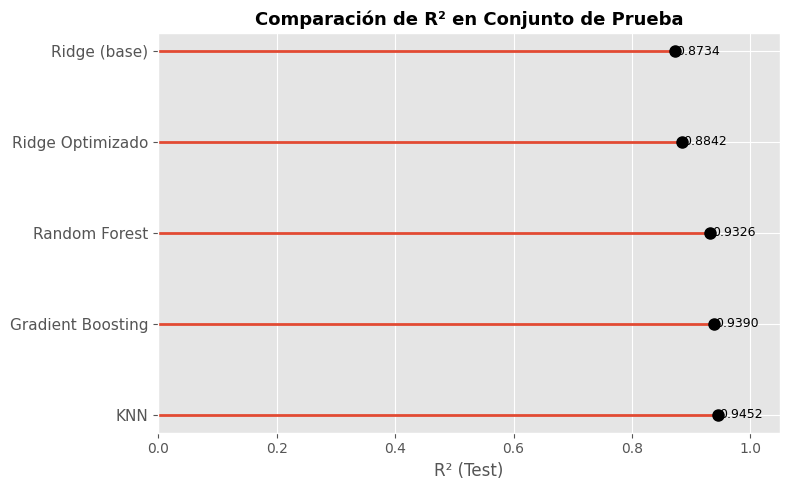

In [ ]:
# PUNTO 8 - Gráfica comparativa de R² por modelo

error_modelos = pd.DataFrame({
    'modelo': ['Ridge (base)', 'Ridge Optimizado', 'KNN', 'Random Forest', 'Gradient Boosting'],
    'r2': [
        r2_score(y_test, pipe.predict(X_test)),
        r2_ridge,
        r2_knn,
        r2_rf,
        r2_gb
    ]
})

error_modelos = error_modelos.sort_values('r2', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hlines(error_modelos.modelo, xmin=0, xmax=error_modelos.r2, linewidth=2)
ax.plot(error_modelos.r2, error_modelos.modelo, 'o', color='black', markersize=8)

for i, (r2, modelo) in enumerate(zip(error_modelos.r2, error_modelos.modelo)):
    ax.text(r2 + 0.002, modelo, f'{r2:.4f}', va='center', fontsize=9)

ax.tick_params(axis='y', which='major', labelsize=11)
ax.set_title('Comparación de R² en Conjunto de Prueba', fontweight='bold', fontsize=13)
ax.set_xlabel('R² (Test)')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

---
# PUNTO 9: Justificación del Mejor Modelo

En base a los resultados obtenidos, se selecciona como mejor modelo aquel que presenta el mayor R² en el conjunto de prueba, ya que es el que mejor logra explicar la variabilidad del precio de las viviendas con datos que no fueron utilizados en el entrenamiento.

**¿Por qué se elige ese modelo?**

El modelo que presentó el mejor desempeño fue KNN optimizado, obteniendo un R² de 0.9452 en el conjunto de prueba. Esto indica que el modelo logra explicar aproximadamente el 94.52% de la variabilidad del precio de las viviendas, lo que refleja un buen nivel de ajuste.

En cuanto a las métricas de error, el modelo obtuvo un MAE de $8,813 USD, lo que significa que en promedio las predicciones se alejan del valor real en ese monto. Por otro lado, el RMSE fue de $18,802 USD, lo que permite observar el impacto de errores más grandes dentro del modelo.

Si bien KNN presenta el mejor resultado en términos de métricas, es importante considerar que se utilizó un valor de n_neighbors = 1, lo que podría generar cierto sobreajuste a los datos de entrenamiento. En este contexto, modelos como Gradient Boosting, que también presentan un buen desempeño (R² cercano a 0.94), pueden ser una alternativa más estable para escenarios reales.

En conclusión, el modelo desarrollado permite predecir precios de viviendas con un buen nivel de precisión, capturando de manera adecuada las relaciones entre las variables del dataset.